In [78]:
from minio import Minio
import s3fs
import os
import matplotlib.pyplot as plt
import xarray as xr
import pickle
import numpy as np
from sympl import get_constant
import metpy
from metpy.units import units
import matplotlib.pylab as pl
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
from matplotlib.ticker import ScalarFormatter

fs = s3fs.S3FileSystem(
    client_kwargs={
        "endpoint_url": "http://192.168.1.237:9000"
    },
    key="d0d250b2541ac33f4660",
    secret="2fb32d964768bc94a3c0"
)

output_dir='/home/data/lab_project2/Steve/model_runs/dry_land/scratch/'
base_path = "climt-long-runs/dry-land/regrid-data/"
plot_path='/home/data/lab_project2/Steve/model_runs/plotting/dl-plots/'

Rd = get_constant('gas_constant_of_dry_air', 'J kg^-1 K^-1')
Cp =\
    get_constant('heat_capacity_of_dry_air_at_constant_pressure',
                 'J kg^-1 K^-1')
g=get_constant('gravitational_acceleration',
                 'm s^-2') 

In [ ]:
latc=45
output_file=output_dir+'hw_'+str(latc)
with open(output_file, 'rb') as f:
    hw_master=pickle.load(f)
    
target_lons = [145] #np.arange(5, 355, 70)

mask = [lon in target_lons for lon in hw_master['lonc']]
hw_master = {key: [vals[i] for i, m in enumerate(mask) if m]
               for key, vals in hw_master.items()}

    
hw_index=1
y=1
loop=0
sensible_flux = {'index':[],'flux':[], 'lonc':[]}
#dse_master={'index':[], 'T':[], 'lonc':[], 'dse_low':[], 'dse_tend_low':[],
#              'intensity':[], 'duration':[], 'maximum':[]}

full_length=len(hw_master['index'])
while hw_index<=full_length:
    r=hw_master['run'][hw_index-1]
    zarr_path = base_path+"run"+str(r)+"/year"+str(y)
    ds = xr.open_zarr(fs.get_mapper(zarr_path))

    while(True):
        time_slice=hw_master['time'][hw_index-1]
        time_center = time_slice[len(time_slice)//2]
        try:
            ds_hw=ds.sel({'time':time_center})
            print(hw_index, hw_master['index'][hw_index-1]);loop=0
            sensible_flux['flux'].append(ds_hw['surface_upward_sensible_heat_flux'].values)
        
            for e in hw_master.keys():
                if e in sensible_flux.keys():
                    sensible_flux[e].append(hw_master[e][hw_index-1])
            
            hw_index=hw_index+1
            if hw_index>full_length:
                break
        except KeyError:
            loop=loop+1
            if loop>20:
                print('skipping!')
                hw_index=hw_index+1
                loop=0
                break
            if y<20:
                y=y+1
            else:
                y=1
            break

output_file=output_dir+'sensible_flux_'+str(latc)
if not os.path.isfile(output_file):
    with open(output_file, 'wb') as f:
        pickle.dump(sensible_flux, f)

In [58]:
latc = 45

climfile=output_dir+'climatology'
ds_clim =xr.open_dataset(climfile, engine='zarr')
ds_clim['surface_upward_sensible_heat_flux'].values

output_file=output_dir+'sensible_flux_'+str(latc)
with open(output_file, 'rb') as f:
    sensible_flux=pickle.load(f)
    
array = np.array(sensible_flux['flux'])
mean_array = np.mean(array, axis=0)
anomaly = mean_array-ds_clim['surface_upward_sensible_heat_flux'].values


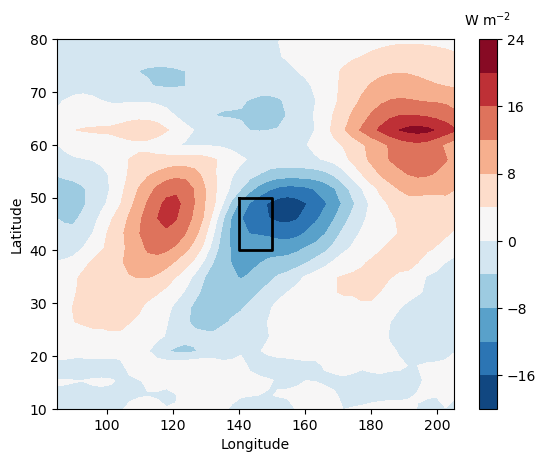

In [84]:
anomaly = mean_array-ds_clim['surface_upward_sensible_heat_flux'].values
lat = ds_clim['lat']
lon = ds_clim['lon']
lonc = 145
lat_min, lat_max = latc+5, latc-5    
lon_min, lon_max = lonc-5, lonc+5

# Draw the box
plt.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
         [lat_min, lat_min, lat_max, lat_max, lat_min],
         color='k', linewidth=2)

lim = max(anomaly.max(), abs(anomaly.min()))
cf = plt.contourf(lon, lat, anomaly, cmap='RdBu_r', levels=12)

cb = plt.colorbar(cf)
cb.ax.set_title(r'W m$^{-2}$', pad=10, fontsize=10)  
plt.xlim(85, 205)
plt.ylim(10, 80,)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.savefig(plot_path+'6.pdf', bbox_inches='tight')
plt.savefig(plot_path+'6.jpg',dpi=600, bbox_inches='tight')